In [30]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
from sklearn.linear_model import LinearRegression
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load data
df = pd.read_parquet('ready_data_2.parquet')
df2 = pd.read_parquet('ready_targets.parquet')
df.head()


,TransactionId,Lat,Lon,BuildingAge,UtilityArea,LotArea,QualityScore,CloseToBeach,EnergyPerformance,EnergyClass,...,MunicipalityMoveInFromCountyFrac,MunicipalityMoveOutToCountyFrac,MunicipalityMoveInFrac2yrChangeMean,MunicipalityMoveOutFrac2yrChangeMean,MunicipalityMoveInFromCountyFrac2yrChangeMean,MunicipalityMoveOutToCountyFrac2yrChangeMean,MunicipalityPopulationMeanDeviation,MedianRentMunicipality,MedianRentMunicipality2yrFracChangeMean,MedianRentMunicipalityMeanDeviation
0,10006194,56.742153,16.291778,48,143,480,36,0,60.0,0.125,...,0.025551,0.021314,0.001816,0.004082,0.000930,0.003437,4.373830,1155.0,0.091030,1.123790
1,10006232,57.278909,13.646019,54,120,750,32,0,114.0,0.125,...,0.010123,0.013869,-0.007777,0.006713,-0.001110,0.002518,1.843030,999.0,0.013451,0.972005
2,10006302,58.328009,15.103299,47,169,592,30,0,0.0,0.000,...,0.034871,0.028112,-0.003267,0.003278,-0.000932,0.000765,1.738860,1046.0,0.075010,1.017735
3,10006371,57.739437,14.122176,128,250,3311,30,0,88.0,0.375,...,0.013410,0.012764,-0.001062,0.001830,0.000457,0.000039,8.857676,1059.0,0.061507,1.030384
4,10006399,57.784585,16.146614,112,87,3406,28,0,101.0,0.500,...,0.006766,0.006466,-0.001024,-0.000181,0.000441,0.000045,2.279611,909.0,0.009151,0.884437


In [31]:
def remove_non_numbers(data):
    """Remove colums with data which are not numbers and return the matrix, without the columns, and the indexes of the removed rows."""
    del_data = data.copy()
    del_idx = {}

    # Removing all non int or float type features looping from the end.
    iterate = len(del_data[0,:])-1
    for i in range(iterate+1):
        if type(del_data[0,iterate-i]) != float and type(del_data[0,iterate-i]) != int:
            del_data = np.delete(del_data, obj=iterate-i, axis=1)
            del_idx[iterate-i] = iterate-i

    return del_data, del_idx


def normalize_feature(feature):
    """Min-max normalization. This retains the relative position of the data points."""
    return (feature-np.min(feature)) / (np.max(feature)-np.min(feature)), np.max(feature), np.min(feature)


def normalize(data, axis=1):
    """Using the normalize_feature function on an np.array along a chosen axis."""
    norm_data = np.zeros_like(data)
    normalization_variables = np.zeros((2, np.shape(data)[1])) # row 1: max value, row 2: min value

    for i in range(data.shape[axis]):
        norm_data[:,i], normalization_variables[0, i], normalization_variables[1, i] = normalize_feature(data[:,i])
    return norm_data, normalization_variables


def clustering(data, cluster_size=10, min_samples=10, distance_type='euclidean'):
    """Takes data, minimum cluster size, distance metric and returns an array of the data with an added column at index 0 with the cluster label and the number of clusters."""
    clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, min_samples=min_samples ,  metric=distance_type)    # , approx_min_span_tree=True, algorithm='boruvka_balltree'
    clusterer.fit(data)
    return clusterer.labels_.max()+1 , np.insert(data, 0, clusterer.labels_.flatten(), axis=1)





def reduce_dimension(vector,clusters):
    """Takes a vector and a set of clusters and reduces the vectors dimension to the number of clusters using the clusters as a basis."""
    # Vector projection
    transformation_matrix = np.zeros([len(clusters), len(vector)])

    for i in clusters:
        transformation_matrix[i] = center_of_mass(clusters[i])

    reduced_vector = transformation_matrix * vector
    return reduced_vector


def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)


def compare_Euclidean(reference, comparables, k=3):
    """Takes a reference point and a matrix of comparable points and returns the first column of the comparable points (ID) and
    the Euclidean distances sorted by distance from low to high."""

    sq_compare = np.square(comparables[:,1:] - reference[1:])
    sum_compare = np.sum(sq_compare, axis=1)
    Euc_compare = np.sqrt(sum_compare)
    Euc_compare = np.vstack((comparables[:, 0], Euc_compare)).T

    sorted_dis = Euc_compare[Euc_compare[:, 1].argsort()]   # Sort Euc_compare

    return sorted_dis[0:k, :]

def show_clusters_in_latlon(data, sorted_clusters, number_of_clusters, clusterspan, lat_index=2, lon_index=3):
    """Creates a 3D plot of the clusters and their center of mass."""

    fig = plt.figure(figsize = (10,10))
    ax = plt.axes()
    ax.grid()

    cmap = get_cmap((number_of_clusters+1)*2)

    for i in range(1,number_of_clusters+1):
        x1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), lat_index]
        y1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), lon_index]
        ax.scatter(x1, y1, c = cmap(i), s = 1)

    ax.set_title('Scatter Plot')

    # Set axes label
    ax.set_xlabel('x', labelpad=20)
    ax.set_ylabel('y', labelpad=20)

In [32]:
# Chaning to numpy array
def dataframe_to_numpy(dataframe):
    dataframe = dataframe.fillna(0)
    data = dataframe.to_numpy()


    data, removed_indices = remove_non_numbers(data)
    print("Removed indices:", removed_indices)



    data = data.astype(float) # Changing from type object to float so that numpy functions work properly.
    return data

Transaction_ID = df.iloc[:, 0]
# Transaction_ID = Transaction_ID.to_numpy()
# Transaction_ID = Transaction_ID.astype(np.float64)
# print(f'ID0: {Transaction_ID}, type: ')
# df = df.drop("TransactionId", axis=1)

data = dataframe_to_numpy(df)
targets = df2.values# dataframe_to_numpy(df2)
# targets = targets.values # .reshape(np.shape(targets)[0], 1)


# Divide the data set into training and testing data

training_data, testing_data, training_targets, testing_targets = train_test_split(data, targets, test_size=0.2, random_state=42)

testing_data, validation_data, testing_targets, validation_targets = train_test_split(testing_data, testing_targets, test_size=0.5, random_state=42)

print('X1 shape: ', training_data.shape)
print('X2 shape: ', testing_data.shape)
print('X3 shape: ', validation_data.shape)
print('X4 shape: ', training_targets.shape)
print('X5 shape: ', testing_targets.shape)
print('X6 shape: ', validation_targets.shape)



Removed indices: {0: 0}
X1 shape:  (73304, 164)
X2 shape:  (9163, 164)
X3 shape:  (9163, 164)
X4 shape:  (73304, 1)
X5 shape:  (9163, 1)
X6 shape:  (9163, 1)


In [33]:
datapoints = 2000
training_data, testing_data, training_targets, testing_targets, validation_data, validation_targets = training_data[0:datapoints, :], testing_data[0:datapoints, :], training_targets[0:datapoints, :], testing_targets[0:datapoints, :], validation_data[0:datapoints, :], validation_targets[0:datapoints, :]

In [34]:
# Normalizing the data
norm_data, normalization_variables = normalize(training_data)
norm_targets, max_targets, min_targets = normalize_feature(training_targets)

norm_testing_targets = (testing_targets-min_targets)/(max_targets-min_targets)
norm_validation_targets = (validation_targets-min_targets)/(max_targets-min_targets)
norm_validation_data = (validation_data-normalization_variables[1])/(normalization_variables[0]-normalization_variables[1])
norm_testing_data = (testing_data-normalization_variables[1])/(normalization_variables[0]-normalization_variables[1])
print(np.shape(norm_data))

(2000, 164)


# Clustering

In [42]:

def create_clusterspan(sorted_clusters, number_of_clusters):
    clusterspan = np.zeros(number_of_clusters+2)

    for i in range(0, number_of_clusters+1):
        clusterspan[i+1] = clusterspan[i] + np.shape(sorted_clusters[np.where(sorted_clusters[:,0] == i)])[0]

    clusterspan[-1] = np.shape(sorted_clusters)[0]
    return clusterspan


def silhouette(SC, NC):
    labels = SC[:, 0]
    silhouettes = metrics.silhouette_samples(SC[:, 1:], labels)
    cluster_silhouettes = np.zeros((NC, 2))
    
    for i in range(1, NC+1):
        # print(i, NC)
        cluster_silhouettes[i-1,:] = i, np.mean(silhouettes[np.where(SC[:, 0] == i)])

    return np.mean(silhouettes), cluster_silhouettes



def optimal_cluster_size(data, max_MCS = 9000, min_MCS = 2000, step_size = 1000, max_recursion = 7, recursion = 0, first_calc=0):
    print(f'Recursion: {recursion}, data shape: {np.shape(data)}, min_MCS: {min_MCS}')
    backup = min_MCS 
    
    if first_calc !=0:
        min_MCS = first_calc
    
    max_iterations = (max_MCS-min_MCS) // step_size + 1
    Sil_mat = np.zeros((max_iterations, 3))

    cluster_mat = np.zeros((np.shape(data)[0], np.shape(data)[1]+1, max_iterations)) # For saving results

    best_silhouette = -1
    best_index = 0
    best_cluster_index = 0

    for MCS in range(min_MCS, max_MCS+1, step_size): # range(2, data_points): # MCS = minimum cluster size  range(9, 11): # 
        index = (MCS-min_MCS)//step_size

        number_of_clusters, clustered_data = clustering(data, cluster_size=MCS, min_samples=2)
        

        if number_of_clusters < 2:
            Sil_mat[index] = MCS, 0, number_of_clusters
            print(f'{MCS} skipped because number of clusters < 2.')
            break

        clustered_data[:, 0] += 1
        

        sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation

        cluster_mat[:,:, index] = sorted_clusters

        clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
        # print(clusterspan)


        average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
        # print(cluster_silhouettes)

        if average_silhouette > best_silhouette:
            best_silhouette, best_index, best_cluster_index = average_silhouette, index, np.argmax(cluster_silhouettes[:, 1])

        Sil_mat[index] = MCS, average_silhouette, number_of_clusters

    # print(best_silhouette, best_index, best_cluster_index)

    if best_silhouette == -1:
        print(f'Stop. Cannot cluster further.')
        print('data: ', np.shape(data))
        return np.insert(data, 0, 1, axis=1)

    # print(Sil_mat)
    min_MCS = backup
    # b = a[np.where(a[1] < 3)]

    cluster_mat_best = cluster_mat[:, :, best_index]
 
    best_cluster = cluster_mat_best[np.where(cluster_mat_best[:, 0] == best_cluster_index)]
    remaining_clusters = cluster_mat_best[np.where(cluster_mat_best[:, 0] != best_cluster_index)]
    size_bc = np.shape(best_cluster)[0]
    size_rc = np.shape(remaining_clusters)[0]

    if recursion < max_recursion and size_bc > 0 and size_rc > 0:
        if  size_bc > min_MCS and size_bc > 3:
            # print(f'new max: {np.min([max_MCS, size_bc-2])}')
            new_min_bc = np.max((int(size_bc/2), 2))
            partition_1 = optimal_cluster_size(best_cluster[:, 1:], np.min([max_MCS, size_bc-2]), np.min([min_MCS, new_min_bc]), step_size=step_size, max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_1 = best_cluster

        if  size_rc > min_MCS and size_rc > 3:
            # print(f'new max: {np.min([max_MCS, size_rc-2])}')
            new_min_rc = np.max((int(size_rc/2), 2))
            partition_2 = optimal_cluster_size(remaining_clusters[:, 1:], np.min([max_MCS, size_rc-2]), np.min([min_MCS, new_min_rc]), step_size=step_size, max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_2 = remaining_clusters

        if np.min(partition_1[:,0] == 0): # All points in partition_1 should belong to a cluster
            partition_1[:, 0] += 1
    else:
        partition_1 = best_cluster
        partition_2 = remaining_clusters
        # print(partition_2)

    partition_3 = partition_2[np.where(partition_2[:, 0] == 0)]
    partition_2 = partition_2[np.where(partition_2[:, 0] != 0)]

    if np.shape(partition_1)[0] > 0:
        partition_2[:, 0] += np.max(partition_1[:,0])

    print(f'p1: {np.shape(partition_1)}, p2: {np.shape(partition_2)}, p3: {np.shape(partition_3)}')

    return np.vstack((partition_1, partition_2, partition_3))

# Normalizing the data
# norm_data, normalization_variables = normalize(training_data)
# print(np.shape(norm_data))

optimal_clustering = optimal_cluster_size(norm_data, 20, 4, 2)
print(optimal_clustering)

Recursion: 0, data shape: (2000, 164), min_MCS: 4
Recursion: 1, data shape: (1885, 164), min_MCS: 4
Recursion: 2, data shape: (22, 164), min_MCS: 4
8 skipped because number of clusters < 2.
Recursion: 3, data shape: (11, 164), min_MCS: 4
4 skipped because number of clusters < 2.
Stop. Cannot cluster further.
data:  (11, 164)
Recursion: 3, data shape: (11, 164), min_MCS: 4
4 skipped because number of clusters < 2.
Stop. Cannot cluster further.
data:  (11, 164)
p1: (11, 165), p2: (11, 165), p3: (0, 165)
Recursion: 2, data shape: (1863, 164), min_MCS: 4
Recursion: 3, data shape: (26, 164), min_MCS: 4
6 skipped because number of clusters < 2.
Recursion: 4, data shape: (10, 164), min_MCS: 4
4 skipped because number of clusters < 2.
Stop. Cannot cluster further.
data:  (10, 164)
Recursion: 4, data shape: (16, 164), min_MCS: 4
6 skipped because number of clusters < 2.
Recursion: 5, data shape: (7, 164), min_MCS: 3
3 skipped because number of clusters < 2.
Stop. Cannot cluster further.
data:  

c:\Users\Projektlotsarna\anaconda3\envs\Machine_Learning\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Projektlotsarna\anaconda3\envs\Machine_Learning\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Projektlotsarna\AppData\Local\Temp\ipykernel_33824\1615709636.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
C:\Users\Projektlotsarna\AppData\Local\Temp\ipykernel_33824\1615709636.py:84: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use 

avg sil: -0.0953436411857417 [[ 1.00000000e+00  1.49018541e-01]
 [ 2.00000000e+00  9.50842709e-02]
 [ 3.00000000e+00  1.25526981e-01]
 [ 4.00000000e+00 -9.69188295e-02]
 [ 5.00000000e+00  9.99915107e-03]
 [ 6.00000000e+00  2.23990618e-01]
 [ 7.00000000e+00  1.74791097e-01]
 [ 8.00000000e+00             nan]
 [ 9.00000000e+00  1.97904279e-01]
 [ 1.00000000e+01  1.52481753e-01]
 [ 1.10000000e+01 -1.11414000e-01]
 [ 1.20000000e+01             nan]
 [ 1.30000000e+01             nan]
 [ 1.40000000e+01  2.40824674e-01]
 [ 1.50000000e+01  1.07417640e-01]
 [ 1.60000000e+01  1.19395521e-01]
 [ 1.70000000e+01             nan]
 [ 1.80000000e+01  2.06002596e-01]
 [ 1.90000000e+01 -1.94311170e-02]
 [ 2.00000000e+01 -1.08796395e-01]
 [ 2.10000000e+01  2.09136063e-02]
 [ 2.20000000e+01  1.08788966e-01]
 [ 2.30000000e+01  1.17436562e-01]
 [ 2.40000000e+01  2.68881547e-01]
 [ 2.50000000e+01 -2.29846582e-01]
 [ 2.60000000e+01 -9.29307485e-02]
 [ 2.70000000e+01 -8.91027506e-02]
 [ 2.80000000e+01 -2.01014

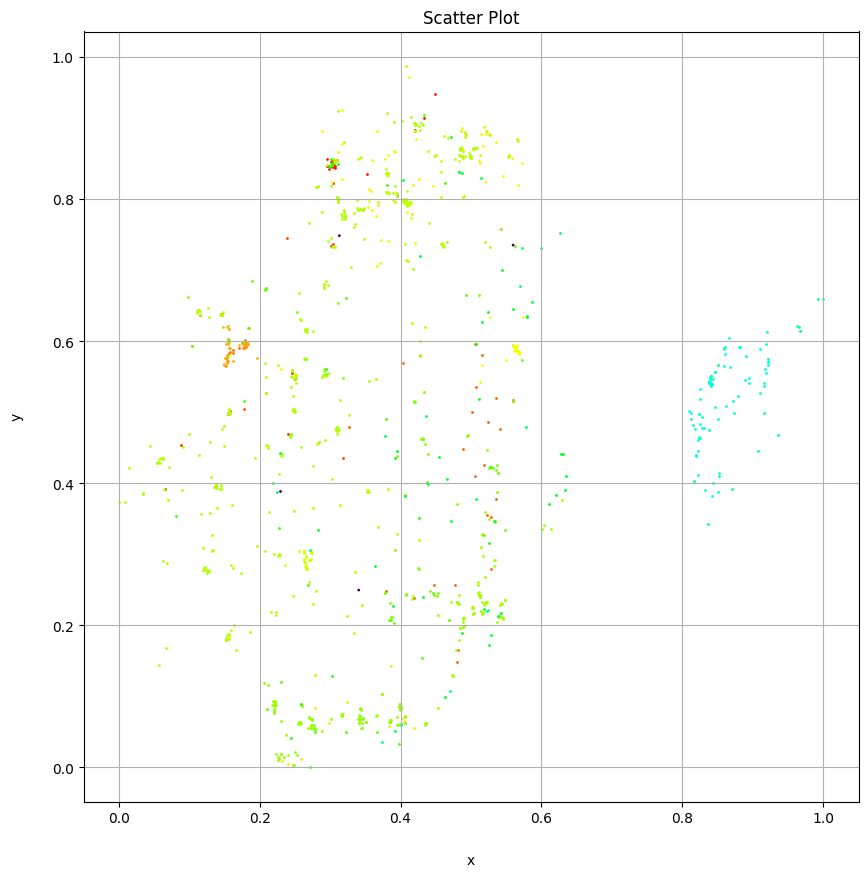

In [43]:
sorted_clusters = optimal_clustering[optimal_clustering[:, 0].argsort()] # sorting the clustered data by cluster affiliation
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
print('avg sil:', average_silhouette, cluster_silhouettes, 'argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(norm_data, sorted_clusters, number_of_clusters, clusterspan,2, 1)

In [37]:
def center_of_mass(number_of_clusters, clusters):
    """Takes a number of clusters and a matrix with points declaring where the first column references which cluster to which the point belongs and
    the rest the coordinates of the point."""
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector

def center_of_mass(number_of_clusters, clusters):

    cluster_centers = np.zeros((number_of_clusters, np.shape(clusters)[1]))
    print(cluster_centers.shape)
    # print(clusters[np.where(clusters[:,0] == 1)])
    # balancing_vector = np.zeros_like
    for i in range(1, number_of_clusters+1):
        cluster_x = clusters[np.where(clusters[:,0] == i)]
        print(np.shape(cluster_x))
        cluster_centers[i-1,:] = np.sum(cluster_x, axis=0) / np.shape(cluster_x)[0]

    return cluster_centers


def vector_norm(vector):
    return np.sqrt(vector @ vector.T)

def create_unit_vector(vector):
    """Takes a vector and creates a unit vector in the same direction."""
    unit_vector = vector / vector_norm(vector)
    return unit_vector

def create_basis(centers_of_mass):
    """Takes the centers_of_mass array and outputs a transformation matrix."""
    basis = np.zeros_like(centers_of_mass[:, 1:])
    for i in range(len(centers_of_mass[:, None])):
        basis[i] = create_unit_vector(centers_of_mass[i, 1:])

    return basis

centers_of_mass = center_of_mass(number_of_clusters, sorted_clusters)
print(centers_of_mass)
transformation_matrix = create_basis(centers_of_mass)

"""
print(np.shape(transformation_matrix@norm_data.T))
print(centers_of_mass)
print(transformation_matrix)
print(transformation_matrix[1,:]@transformation_matrix[1,:].T)
print(transformation_matrix@norm_data.T)
"""

embedded_data = (transformation_matrix@norm_data.T).T

# norm_embedded_data = normalize(embedded_data)

# print(embedded_data)
print(np.shape(embedded_data))
# print(norm_embedded_data)

(45, 165)
(11, 165)
(11, 165)
(10, 165)
(7, 165)
(9, 165)
(24, 165)
(8, 165)
(0, 165)
(17, 165)
(10, 165)
(16, 165)
(0, 165)
(0, 165)
(28, 165)
(45, 165)
(28, 165)
(0, 165)
(24, 165)
(99, 165)
(342, 165)
(89, 165)
(116, 165)
(36, 165)
(23, 165)
(13, 165)
(9, 165)
(8, 165)
(8, 165)
(5, 165)
(0, 165)
(4, 165)
(4, 165)
(38, 165)
(5, 165)
(5, 165)
(6, 165)
(4, 165)
(6, 165)
(15, 165)
(3, 165)
(1, 165)
(13, 165)
(9, 165)
(18, 165)
(35, 165)
[[ 1.          0.86718432  0.3432475  ...  0.76226077  0.38001168
   0.82058968]
 [ 2.          0.84742986  0.30268654 ...  0.79141746  0.39860378
   0.81462471]
 [ 3.          0.52081231  0.19812872 ...  0.80666118  0.38089755
   0.79602216]
 ...
 [43.          0.46826191  0.85362593 ...  0.86302997  0.35893359
   0.93163129]
 [44.          0.5413978   0.87051353 ...  0.94197734  0.43343327
   0.94484336]
 [45.          0.51822781  0.85191034 ...  0.34694549  0.27895024
   0.37268857]]
(2000, 45)


C:\Users\Projektlotsarna\AppData\Local\Temp\ipykernel_33824\2297824174.py:22: RuntimeWarning: invalid value encountered in divide
  cluster_centers[i-1,:] = np.sum(cluster_x, axis=0) / np.shape(cluster_x)[0]


1 0.8671843224947197 0.34324750348095134 0.06620752984389348
2 0.8474298562125153 0.30268653707350884 0.05757575757575757
3 0.5208123093864029 0.19812871547129934 0.06808080808080808
4 0.5992995429244498 0.20000526085835305 0.04761904761904761
5 0.5389961271977116 0.15517873467188195 0.06588103254769921
6 0.40724756216665975 0.5011419764492073 0.08855218855218855
7 0.5896703317288414 0.16841484149128041 0.059595959595959605
8 nan nan nan
9 0.5852348479611268 0.1643126762793029 0.06446821152703505
10 0.5917360466339958 0.16678162169388394 0.04555555555555556
11 0.59885360944003 0.15686327190011964 0.05214646464646464
12 nan nan nan
13 nan nan nan
14 0.06663989475570377 0.308725553537531 0.06962481962481962
15 0.8293529953600594 0.41048272684141923 0.0924579124579124
16 0.5889624752415374 0.5590425995748338 0.06406926406926407
17 nan nan nan
18 0.29242599309660555 0.2650881761298515 0.04591750841750842
19 0.8334891245269233 0.4429768560045557 0.049086827874706675
20 0.5610053182067322 0.

C:\Users\Projektlotsarna\AppData\Local\Temp\ipykernel_33824\1615709636.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
C:\Users\Projektlotsarna\AppData\Local\Temp\ipykernel_33824\4142778389.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
C:\Users\Projektlotsarna\AppData\Local\Temp\ipykernel_33824\4142778389.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have preced

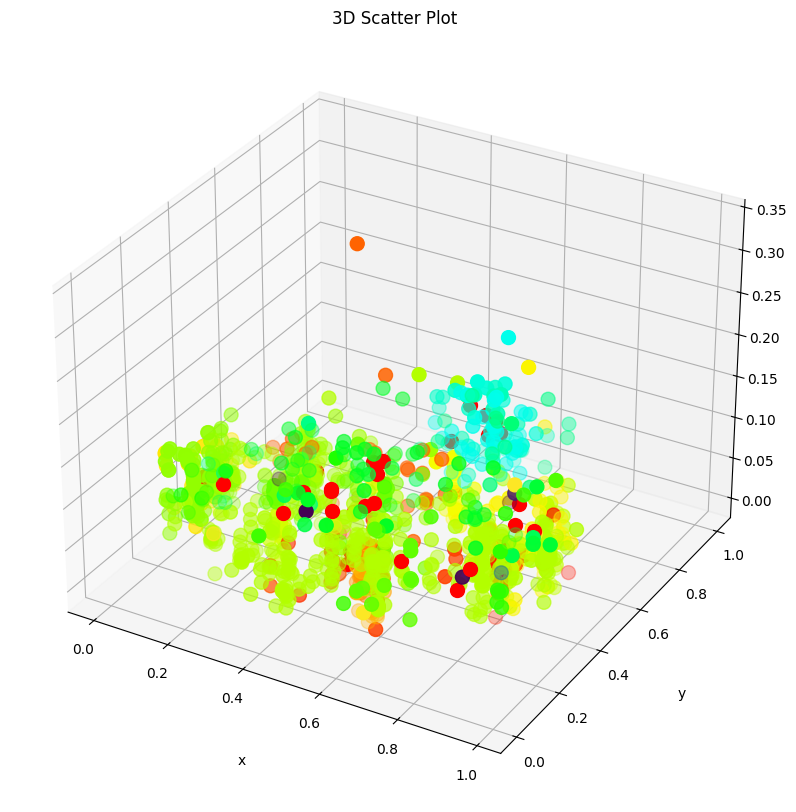

In [38]:
def show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan):
    """Creates a 3D plot of the clusters and their center of mass."""
    
    # %matplotlib widget

    fig = plt.figure(figsize = (10,10))
    ax = plt.axes(projection='3d')
    ax.grid()

    cmap = get_cmap((number_of_clusters+1)*2)

    for i in range(1,number_of_clusters+1):
        x1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 1]
        y1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 2]
        z1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 3]
        ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
        xc1,yc1,zc1 = centers_of_mass[i-1, 1:4]
        print(i, xc1, yc1, zc1)
        ax.scatter(xc1,yc1,zc1, c = cmap(-i), s = 100)

    # xc2,yc2,zc2 = centers_of_mass[1, 1:4]

    # print("1", xc1, yc1, zc1)
    # print("2", xc2, yc2, zc2)

    ax.set_title('3D Scatter Plot')

    # Set axes label
    ax.set_xlabel('x', labelpad=20)
    ax.set_ylabel('y', labelpad=20)
    ax.set_zlabel('z', labelpad=20)

show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)

In [39]:

model = LinearRegression()

embedded_testing_data = (transformation_matrix@norm_testing_data.T).T

model.fit(embedded_data, norm_targets)
prediction = model.predict(embedded_testing_data)

print(prediction, norm_testing_targets, 'diff:', np.mean(abs(prediction-norm_testing_targets)))


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
model = LinearRegression()

# embedded_testing_data = (transformation_matrix@norm_testing_data.T).T

model.fit(norm_data, norm_targets)
prediction = model.predict(norm_testing_data)

print(prediction, norm_testing_targets, 'diff:', np.mean(abs(prediction-norm_testing_targets)))


[[ 1.07076269]
 [ 0.60443279]
 [ 0.62524058]
 [ 0.0137181 ]
 [ 0.73165344]
 [ 0.63785814]
 [ 0.593236  ]
 [ 0.60017061]
 [ 0.52599578]
 [ 0.50478267]
 [ 0.73236195]
 [ 0.40156729]
 [ 0.86844591]
 [ 0.48499006]
 [ 0.48454719]
 [ 0.84715011]
 [ 0.35681776]
 [ 0.76094204]
 [ 0.74518201]
 [ 0.84713739]
 [ 0.38697529]
 [ 0.94943775]
 [ 0.58616541]
 [ 0.54850433]
 [ 0.34797148]
 [ 0.43441472]
 [ 0.55361108]
 [ 0.78260669]
 [ 0.21597525]
 [ 0.67616965]
 [ 0.94632186]
 [ 0.47966704]
 [ 0.40841637]
 [ 0.35669501]
 [ 0.73855778]
 [ 0.42770925]
 [ 0.52011424]
 [ 1.03615985]
 [ 0.92407161]
 [ 0.75481251]
 [ 0.53458434]
 [ 0.51086028]
 [ 0.42312825]
 [ 0.42197091]
 [ 0.58412949]
 [ 0.68984715]
 [ 0.54378717]
 [ 0.61286264]
 [ 0.4816121 ]
 [ 0.70994004]
 [ 0.69333601]
 [ 0.14719128]
 [ 0.89602748]
 [ 0.97938945]
 [ 0.33355165]
 [ 0.63113587]
 [ 0.70504609]
 [ 0.42881266]
 [ 0.62480337]
 [ 0.22549722]
 [ 0.71677168]
 [ 0.76513583]
 [ 0.37227643]
 [ 0.77017284]
 [ 0.43322491]
 [ 0.51313611]
 [ 0.44262